In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random
import time
import os
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

# Para que las gráficas se vean directamente en el notebook
%matplotlib inline

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Usando dispositivo: {device}")

clases_cifar = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Carga del dataset crudo (sin normalizar) para las gráficas de exploración
dataset_visual = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)

🚀 Usando dispositivo: cuda
Files already downloaded and verified


c:\GitHub\Programacion\Python\TIA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [52]:


class MasterCNN(nn.Module):
    def __init__(self, input_shape=(3, 32, 32), num_classes=10, 
                 depth=3, filters=[32, 64, 128], kernel_sizes=[3, 3, 3], 
                 pool_sizes=[2, 2, 2], activation_fn=nn.ReLU, 
                 use_batchnorm=True, fc_layers=[512, 256], dropout_p=0.4, epochs=40):
        super(MasterCNN, self).__init__()
        self.epochs = epochs
        
        assert depth == len(filters) == len(kernel_sizes) == len(pool_sizes), \
            "La longitud de filters, kernel_sizes y pool_sizes debe coincidir con 'depth'."
            
        conv_blocks = []
        in_channels = input_shape[0]
        
        for i in range(depth):
            conv_blocks.append(nn.Conv2d(in_channels, filters[i], 
                                         kernel_size=kernel_sizes[i], padding='same'))
            if use_batchnorm:
                conv_blocks.append(nn.BatchNorm2d(filters[i]))
            conv_blocks.append(activation_fn())
            if pool_sizes[i] > 1:
                conv_blocks.append(nn.MaxPool2d(kernel_size=pool_sizes[i]))
            in_channels = filters[i]
            
        self.feature_extractor = nn.Sequential(*conv_blocks)
        
        dummy_input = torch.zeros(1, *input_shape)
        dummy_output = self.feature_extractor(dummy_input)
        flattened_size = dummy_output.view(1, -1).size(1)
        
        fc_blocks = []
        in_features = flattened_size
        
        for fc_dim in fc_layers:
            fc_blocks.append(nn.Linear(in_features, fc_dim))
            fc_blocks.append(activation_fn())
            if dropout_p > 0:
                fc_blocks.append(nn.Dropout(dropout_p))
            in_features = fc_dim
            
        fc_blocks.append(nn.Linear(in_features, num_classes))
        fc_blocks.append(nn.LogSoftmax(dim=1)) 
        
        self.classifier = nn.Sequential(*fc_blocks)
        
    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
    def fit(self, train_loader, val_loader, optimizer, criterion, device, verbose=True):
        history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}
        start_time = time.time()
        
        if verbose:
            print(f"▶ Iniciando entrenamiento CNN por {self.epochs} épocas...")
        
        for epoch in range(self.epochs):
            self.train()
            r_loss, correct_t, total_t = 0.0, 0, 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                r_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                correct_t += (pred == labels).sum().item()
                total_t += labels.size(0)
                
            self.eval()
            rv_loss, correct_v, total_v = 0.0, 0, 0
            with torch.no_grad():
                for vi, vl in val_loader:
                    vi, vl = vi.to(device), vl.to(device)
                    vo = self(vi)
                    rv_loss += criterion(vo, vl).item()
                    _, vp = torch.max(vo, 1)
                    correct_v += (vp == vl).sum().item()
                    total_v += vl.size(0)
            
            history['t_loss'].append(r_loss/len(train_loader))
            history['v_loss'].append(rv_loss/len(val_loader))
            history['t_acc'].append(100 * correct_t/total_t)
            history['v_acc'].append(100 * correct_v/total_v)
            
            if verbose and ((epoch+1) % 5 == 0 or epoch == 0):
                print(f"Época {epoch+1:02d} | Train Loss: {history['t_loss'][-1]:.4f} | Val Acc: {history['v_acc'][-1]:.2f}%")
                
        tiempo_total = time.time() - start_time
        if verbose:
            print(f"✔ Finalizado en: {tiempo_total:.2f}s")
            
        history['time'] = tiempo_total 
        return history

    def evaluate(self, history, test_loader, device, exp_name="CIFAR10_CNN", verbose=True):
        if not os.path.exists("resultados_plots"):
            os.makedirs("resultados_plots")

        # 1. Guardar gráficas de curvas de aprendizaje
        plt.figure(figsize=(14, 5))        
        plt.subplot(1, 2, 1)
        plt.plot(history['t_loss'], label='Train Loss')
        plt.plot(history['v_loss'], label='Val Loss')
        plt.title(f'Pérdida - {exp_name}')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history['t_acc'], label='Train Acc')
        plt.plot(history['v_acc'], label='Val Acc')
        tiempo_total = history.get('time', 0) 
        plt.title(f'Precisión (Tiempo: {tiempo_total:.2f}s)')
        plt.legend()
        plt.savefig(f"resultados_plots/{exp_name}_curvas.png", bbox_inches='tight')
        plt.close() 

        # 2. Realizar predicciones
        self.eval() 
        y_true, y_pred = [], []
        with torch.no_grad():
            for ti, tl in test_loader:
                ti = ti.to(device)
                out = self(ti)
                _, p = torch.max(out, 1)
                y_true.extend(tl.cpu().numpy()) 
                y_pred.extend(p.cpu().numpy())

        # 3. Guardar matriz de confusión
        clases_cifar = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']
        report = classification_report(y_true, y_pred, target_names=clases_cifar, output_dict=True, zero_division=0)
        
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=clases_cifar, yticklabels=clases_cifar)
        plt.title(f'Matriz de Confusión - {exp_name}')
        plt.xlabel('Predicción')
        plt.ylabel('Real')
        plt.savefig(f"resultados_plots/{exp_name}_matriz.png", bbox_inches='tight')
        plt.close()
        
        # 4. Extraer métricas clave
        acc_global = report['accuracy']
        f1_macro = report['macro avg']['f1-score']
        f1_weighted = report['weighted avg']['f1-score']
        
        if verbose:
            print(f"📊 Reportes de {exp_name} generados exitosamente. Acc: {acc_global:.4f}")
            
        # 5. EL RETURN VA AL FINAL DE TODO
        return {
            "accuracy": acc_global,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
            "tiempo_seg": history.get('time', 0)
        }

In [53]:


# 1. Definimos las transformaciones
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)), 
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 2. Cargamos el set de 50k imágenes
dataset_completo = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)

# 3. Partición personalizada (Ejemplo: 80% Train, 20% Validation)
# 40,000 para entrenar, 10,000 para validar hiperparámetros
train_size = 40000
val_size = 10000
train_dataset, val_dataset = random_split(dataset_completo, [train_size, val_size], 
                                          generator=torch.Generator().manual_seed(42))

# 4. El set de TEST (10k originales) se queda aparte para la evaluación final
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

print(f"✅ Datos particionados: Train ({len(train_dataset)}), Val ({len(val_dataset)}), Test ({len(test_dataset)})")


# Epocas y experimentos
num_exp = 15
epocas_por_experimento = 40

Files already downloaded and verified
Files already downloaded and verified
✅ Datos particionados: Train (40000), Val (10000), Test (10000)


⏳ Generando grid de muestras de CIFAR-10...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000150FFB74180>
Traceback (most recent call last):
  File "c:\GitHub\Programacion\Python\TIA\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\GitHub\Programacion\Python\TIA\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


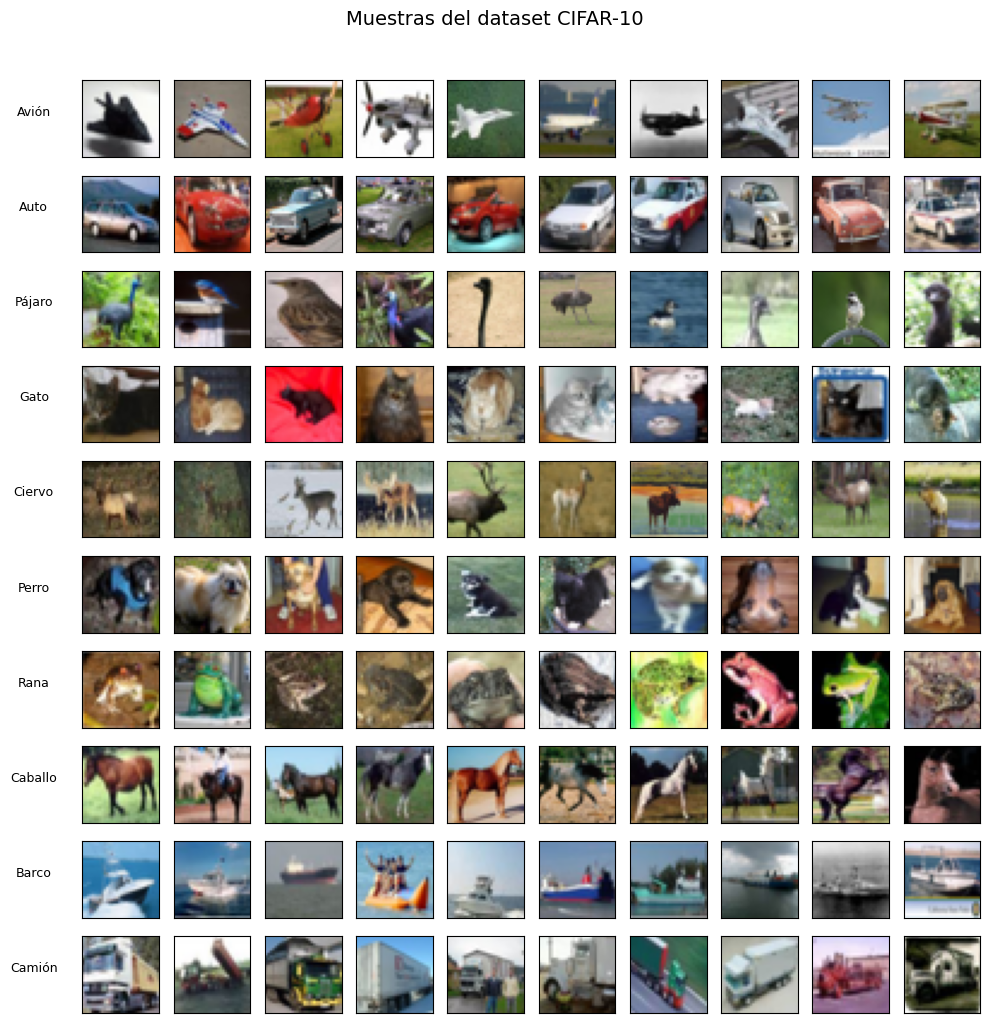

In [54]:
def visualizar_muestras_cifar(dataset_raw, clases):
    print("⏳ Generando grid de muestras de CIFAR-10...")
    muestras = {i: [] for i in range(10)}
    for img, label in dataset_raw:
        if len(muestras[label]) < 10:
            muestras[label].append(img)
        if all(len(v) == 10 for v in muestras.values()):
            break

    fig, axes = plt.subplots(10, 10, figsize=(10, 10))
    fig.suptitle("Muestras del dataset CIFAR-10", fontsize=14, y=1.02)
    
    for class_idx in range(10):
        for img_idx in range(10):
            ax = axes[class_idx, img_idx]
            ax.imshow(muestras[class_idx][img_idx])
            ax.set_xticks([]); ax.set_yticks([])
            if img_idx == 0:
                ax.set_ylabel(clases[class_idx], fontsize=9, rotation=0, labelpad=35, ha='center')
                
    plt.tight_layout()
    plt.show()

# Ejecutar visualización
visualizar_muestras_cifar(dataset_visual, clases_cifar)

⏳ Analizando distribución...


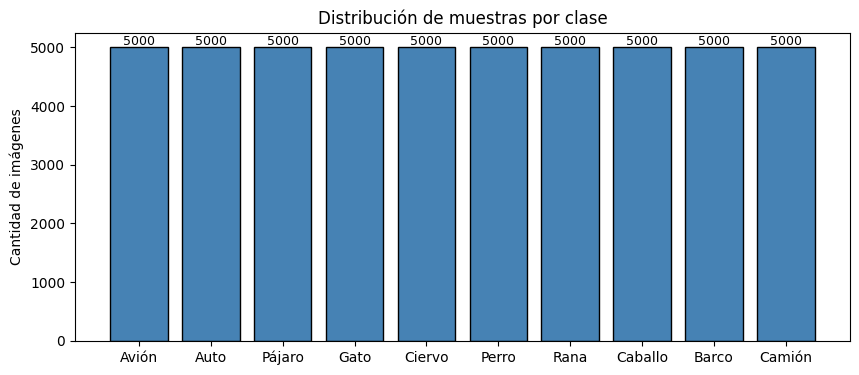

In [55]:
def analizar_distribucion_clases(dataset, clases):
    print("⏳ Analizando distribución...")
    labels = [label for _, label in dataset]
    counts = pd.Series(labels).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(clases, counts.values, color="steelblue", edgecolor="black")
    ax.set_title("Distribución de muestras por clase")
    ax.set_ylabel("Cantidad de imágenes")
    
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontsize=9)
        
    plt.show()

# Ejecutar análisis
analizar_distribucion_clases(dataset_visual, clases_cifar)

In [56]:
def generar_grid_random_search(num_experimentos=10, semilla=42):
    # Fijamos la semilla de numpy para que la grid sea siempre la misma al re-ejecutar
    np.random.seed(semilla)
    configuraciones = []
    
    for i in range(num_experimentos):
        lr = 10**np.random.uniform(-5, -2)
        batch_size = int(2**np.random.randint(5, 10))
        depth = np.random.randint(2, 6) 
        optimizador = np.random.choice(['Adam', 'SGD', 'RMSprop'])
        activacion = np.random.choice(['ReLU', 'ELU', 'Tanh', 'LeakyReLU'])
        base_f = np.random.choice([32, 64])
        dropout_p = np.random.uniform(0.1, 0.5)
        
        config = {
            'exp_id': f"Exp_RS_{i+1:02d}",
            'depth': depth,
            'filters': [int(base_f * (2**j)) for j in range(depth)],
            'kernel_sizes': [3] * depth,
            'pool_sizes': [2] * depth,
            'fc_layers': random.choice([[512], [512, 256]]), # random.choice sigue siendo útil aquí
            'dropout_p': np.round(dropout_p, 3), 
            'lr': np.round(lr, 6),               
            'batch_size': batch_size,
            'optimizer': optimizador,
            'activation': activacion
        }
        configuraciones.append(config)
        
    return configuraciones

# Generar y mostrar la grid de ejemplo
grid_experimentos = generar_grid_random_search(num_experimentos=num_exp, semilla=42)
print(f"✅ Se han generado {num_exp} configuraciones aleatorias.")
pd.DataFrame(grid_experimentos).drop(['filters', 'kernel_sizes', 'pool_sizes'], axis=1).head()

✅ Se han generado 15 configuraciones aleatorias.


,exp_id,depth,fc_layers,dropout_p,lr,batch_size,optimizer,activation
0,Exp_RS_01,4,"[512, 256]",0.339,0.000133,512,RMSprop,LeakyReLU
1,Exp_RS_02,4,[512],0.383,0.000218,128,Adam,LeakyReLU
2,Exp_RS_03,5,[512],0.173,0.000012,64,SGD,ELU
3,Exp_RS_04,3,"[512, 256]",0.109,0.000035,256,SGD,ReLU
4,Exp_RS_05,5,"[512, 256]",0.414,0.000375,64,RMSprop,ELU


In [62]:
def analizar_estadisticas_ranking(resultados_ranking):
    """
    Convierte los resultados en un DataFrame, limpia los porcentajes 
    y calcula estadísticas descriptivas, curtosis y asimetría.
    """
    print("⏳ Calculando estadísticas avanzadas del Random Search...")
    df_resultados = pd.DataFrame(resultados_ranking)

    # Convertimos los strings con "%" de vuelta a valores numéricos (float)
    df_resultados['Acc_num'] = df_resultados['Acc'].str.rstrip('%').astype(float) / 100
    df_resultados['F1_num'] = df_resultados['F1'].str.rstrip('%').astype(float) / 100

    # Columnas numéricas de interés
    columnas_numericas = ['Acc_num', 'F1_num', 'LR', 'Batch']

    # Extraer estadísticas base y añadir curtosis/asimetría
    df_stats = df_resultados[columnas_numericas].describe()
    df_stats.loc['kurtosis'] = df_resultados[columnas_numericas].kurtosis()
    df_stats.loc['skewness'] = df_resultados[columnas_numericas].skew()

    print("\n📊 ESTADÍSTICAS DEL RANDOM SEARCH 📊")
    # Imprimimos nativamente con pandas
    print(df_stats.T.to_string())
    
    return df_resultados

def mostrar_top_modelos(df_resultados, top_n=3, dir_plots="resultados_plots"):
    """
    Ordena el DataFrame usando el desempate estadístico avanzado, selecciona 
    los mejores N modelos y renderiza sus gráficas originales (ya guardadas).
    """
    print(f"\n🏆 LOS {top_n} MEJORES MODELOS (DESEMPATE AVANZADO) 🏆\n" + "="*80)
    
    # 1. LA MAGIA DEL DESEMPATE (Robada del bloque anterior)
    criterios = ['Acc_num', 'Val_Loss', 'F1_num', 'Tiempo(s)', 'Depth']
    orden_ascendente = [False, True, False, True, True]

    # Filtramos para evitar KeyError si alguna columna falta
    criterios_existentes = [c for c in criterios if c in df_resultados.columns]
    orden_existente = [orden_ascendente[i] for i, c in enumerate(criterios) if c in df_resultados.columns]

    # Ordenamos y sacamos el Top
    top_modelos = df_resultados.sort_values(by=criterios_existentes, ascending=orden_existente).head(top_n)

    # Imprimimos la tabla resumen de los ganadores
    columnas_mostrar = ['ID', 'Acc']
    if 'Val_Loss' in df_resultados.columns: columnas_mostrar.append('Val_Loss')
    columnas_mostrar.extend(['F1', 'Optim', 'Act', 'LR', 'Batch'])
    
    print(top_modelos[columnas_mostrar].to_string(index=False))
    print("="*80 + "\n")

    # 2. MOSTRAR GRÁFICAS YA EXISTENTES
    for index, row in top_modelos.iterrows():
        exp_id = row['ID'] # Usamos el ID original, ya no necesitamos el sufijo _GANADOR
        
        print(f"\n🚀 MODELO: {exp_id} | Precisión: {row['Acc']} | Loss: {row.get('Val_Loss', 'N/A')}")
        print("-" * 80)
        
        # Bucle elegante para mostrar ambas imágenes
        for tipo in ['curvas', 'matriz']:
            ruta = f"{dir_plots}/{exp_id}_{tipo}.png"
            
            if os.path.exists(ruta):
                plt.figure(figsize=(12, 5) if tipo == 'curvas' else (7, 7))
                plt.imshow(mpimg.imread(ruta))
                plt.axis('off')
                plt.show()
            else:
                print(f"⚠️ Imagen no encontrada en: {ruta}")


In [63]:
mapa_activaciones = {'ReLU': nn.ReLU, 'ELU': nn.ELU, 'Tanh': nn.Tanh, 'LeakyReLU': nn.LeakyReLU}
resultados_ranking = []

print(f"🚀 Iniciando búsqueda de {len(grid_experimentos)} modelos...")

for conf in grid_experimentos:
    print(f"🔎 Procesando {conf['exp_id']}...")
    
    t_loader = DataLoader(train_dataset, batch_size=conf['batch_size'], shuffle=True, num_workers=2)
    v_loader = DataLoader(val_dataset, batch_size=conf['batch_size'], shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=conf['batch_size'], shuffle=False, num_workers=2)
    
    modelo = MasterCNN(
        input_shape=(3, 32, 32), num_classes=10, depth=conf['depth'],
        filters=conf['filters'], kernel_sizes=conf['kernel_sizes'], pool_sizes=conf['pool_sizes'],
        activation_fn=mapa_activaciones[conf['activation']], use_batchnorm=True,
        fc_layers=conf['fc_layers'], dropout_p=conf['dropout_p'], epochs=epocas_por_experimento
    ).to(device)

    if conf['optimizer'] == 'Adam': opt = optim.Adam(modelo.parameters(), lr=conf['lr'])
    elif conf['optimizer'] == 'SGD': opt = optim.SGD(modelo.parameters(), lr=conf['lr'], momentum=0.9)
    else: opt = optim.RMSprop(modelo.parameters(), lr=conf['lr'])

    hist = modelo.fit(t_loader, v_loader, opt, nn.NLLLoss(), device, verbose=False)
    met = modelo.evaluate(hist, test_loader, device, exp_name=conf['exp_id'], verbose=False)
    
    # ✅ ESTA ES LA LÍNEA QUE FALTABA:
    perdida_final_val = hist['v_loss'][-1]
    
    resultados_ranking.append({
        'ID': conf['exp_id'], 
        'Acc': f"{met['accuracy']*100:.2f}%", 
        'F1': f"{met['f1_macro']*100:.2f}%", 
        'Val_Loss': round(perdida_final_val, 4), # <-- Ahora sí se guarda
        'Tiempo(s)': round(met['tiempo_seg'], 1), 
        'Depth': conf['depth'],
        'Optim': conf['optimizer'], 
        'Act': conf['activation'], 
        'LR': conf['lr'], 
        'Batch': conf['batch_size'],
        'full_conf': conf 
    })


# --- MOSTRAR RANKING FINAL COMPLETO ---
print("\n🏆 RANKING FINAL DETALLADO  🏆")

# Convertimos la lista de resultados a DataFrame
df_ranking = pd.DataFrame(resultados_ranking)

# Usamos el contexto para liberar los límites de visualización solo en este display
with pd.option_context(
    'display.max_rows', None,      # Muestra todas las filas (los 15 modelos)
    'display.max_columns', None,   # Muestra todas las columnas (Acc, Loss, LR, Batch, etc.)
    'display.width', 1000,         # Evita que las columnas salten de línea
    'display.precision', 2         # Ajusta los decimales para lectura limpia
):
    # Ordenamos por Accuracy y quitamos 'full_conf' para que la tabla sea legible
    display(df_ranking.sort_values(by='Acc', ascending=False).drop(columns=['full_conf'], errors='ignore'))

🚀 Iniciando búsqueda de 15 modelos...
🔎 Procesando Exp_RS_01...
🔎 Procesando Exp_RS_02...
🔎 Procesando Exp_RS_03...
🔎 Procesando Exp_RS_04...
🔎 Procesando Exp_RS_05...
🔎 Procesando Exp_RS_06...
🔎 Procesando Exp_RS_07...
🔎 Procesando Exp_RS_08...
🔎 Procesando Exp_RS_09...
🔎 Procesando Exp_RS_10...
🔎 Procesando Exp_RS_11...
🔎 Procesando Exp_RS_12...
🔎 Procesando Exp_RS_13...
🔎 Procesando Exp_RS_14...
🔎 Procesando Exp_RS_15...

🏆 RANKING FINAL DETALLADO  🏆


,ID,Acc,F1,Val_Loss,Tiempo(s),Depth,Optim,Act,LR,Batch
8,Exp_RS_09,85.77%,85.80%,0.49,650.4,3,Adam,LeakyReLU,3.16e-03,128
4,Exp_RS_05,85.60%,85.59%,0.52,869.3,5,RMSprop,ELU,3.75e-04,64
1,Exp_RS_02,85.21%,85.48%,0.49,799.6,4,Adam,LeakyReLU,2.18e-04,128
6,Exp_RS_07,82.04%,82.08%,0.57,825.5,5,Adam,LeakyReLU,3.20e-05,64
13,Exp_RS_14,75.49%,75.20%,0.74,778.6,4,Adam,ReLU,6.70e-05,512
10,Exp_RS_11,73.48%,73.33%,0.83,830.7,3,SGD,Tanh,2.23e-04,64
14,Exp_RS_15,73.15%,73.00%,0.93,608.5,5,RMSprop,Tanh,2.07e-03,256
0,Exp_RS_01,72.99%,72.00%,0.82,806.2,4,RMSprop,LeakyReLU,1.33e-04,512
5,Exp_RS_06,71.67%,71.41%,0.84,784.0,5,Adam,Tanh,4.00e-05,256
7,Exp_RS_08,70.94%,70.91%,0.89,549.2,3,RMSprop,LeakyReLU,8.20e-05,512


⏳ Calculando estadísticas avanzadas del Random Search...

📊 ESTADÍSTICAS DEL RANDOM SEARCH 📊
         count        mean         std        min        25%         50%         75%         max  kurtosis  skewness
Acc_num   15.0    0.710400    0.122994   0.421000   0.673250    0.729900    0.787650    0.857700  0.933273 -0.948735
F1_num    15.0    0.707587    0.126050   0.406400   0.669300    0.720000    0.786400    0.858000  1.081445 -0.969607
LR        15.0    0.000474    0.000904   0.000012   0.000053    0.000086    0.000299    0.003159  5.882772  2.535601
Batch     15.0  243.200000  184.540820  64.000000  64.000000  256.000000  384.000000  512.000000 -1.268657  0.601480

🏆 LOS 3 MEJORES MODELOS (DESEMPATE AVANZADO) 🏆
       ID    Acc  Val_Loss     F1   Optim       Act       LR  Batch
Exp_RS_09 85.77%    0.4911 85.80%    Adam LeakyReLU 0.003159    128
Exp_RS_05 85.60%    0.5199 85.59% RMSprop       ELU 0.000375     64
Exp_RS_02 85.21%    0.4857 85.48%    Adam LeakyReLU 0.000218    128




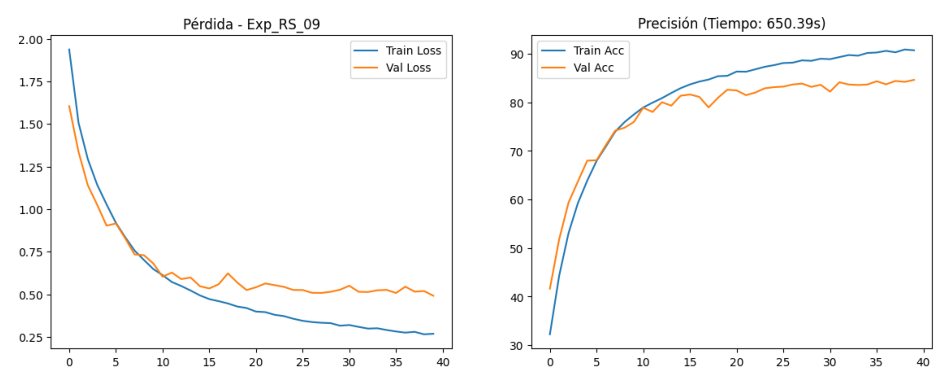

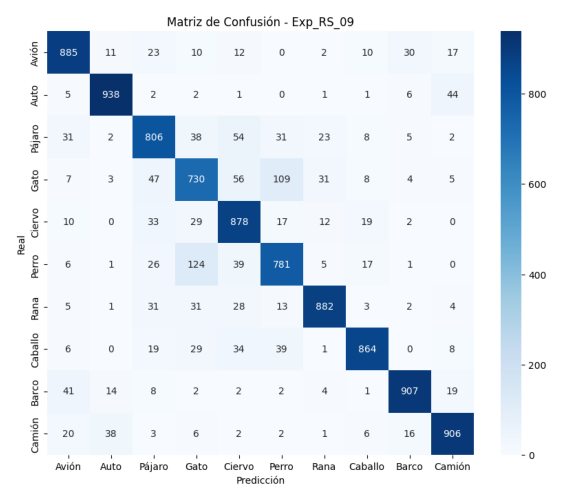


🚀 MODELO: Exp_RS_05 | Precisión: 85.60% | Loss: 0.5199
--------------------------------------------------------------------------------


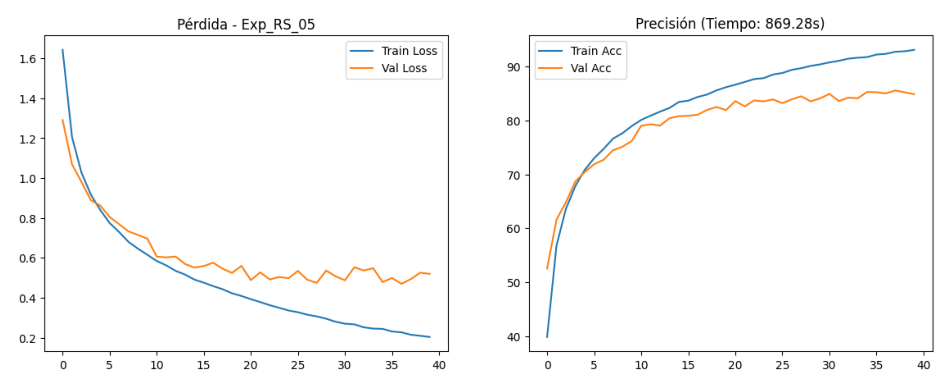

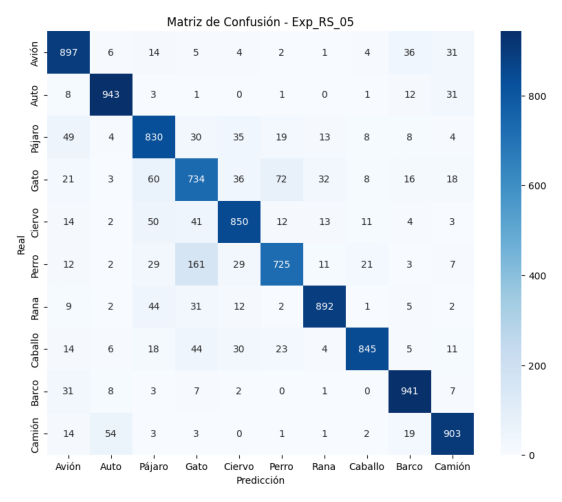


🚀 MODELO: Exp_RS_02 | Precisión: 85.21% | Loss: 0.4857
--------------------------------------------------------------------------------


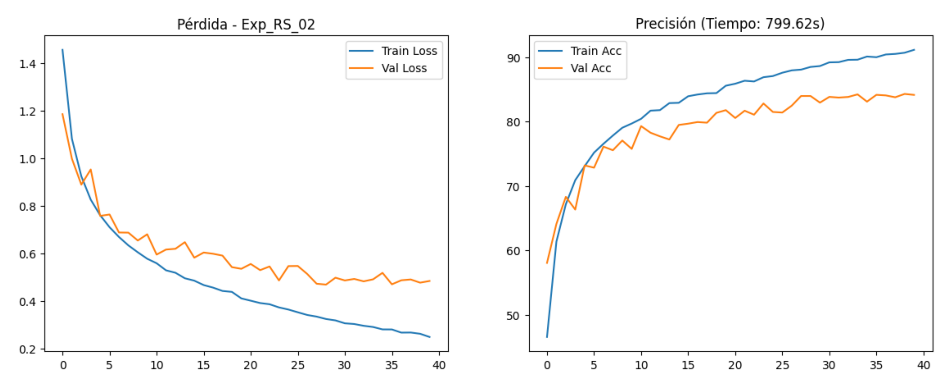

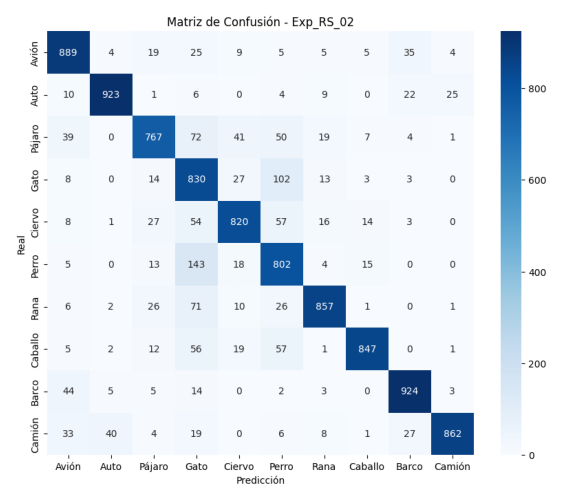

In [64]:
# 2. Generar estadísticas (Asimetría, Curtosis, STD)
df_limpio = analizar_estadisticas_ranking(resultados_ranking)

# 3. Mostrar a los ganadores (Instantáneo, sin reentrenar)
mostrar_top_modelos(df_limpio, top_n=3)